<a href="https://colab.research.google.com/github/UmymaM/ml-dl-cv-fundamentals/blob/main/binary-image-classifier/cats_v_dogs_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!kaggle datasets download -d moazeldsokyx/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/moazeldsokyx/dogs-vs-cats
License(s): CC0-1.0
100% 817M/817M [00:08<00:00, 98.3MB/s]



In [4]:
# since the downloaded file is zipped, we'll have to unzip it using the zipfile lib
import zipfile
zipfile=zipfile.ZipFile('dogs-vs-cats.zip')
zipfile.extractall()
zipfile.close()

In [20]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D,Dropout,BatchNormalization

In [6]:
# generators -> helpful in processing large amounts of data
training_data=keras.utils.image_dataset_from_directory(
    directory="/content/dataset/train",
    labels="inferred",
    label_mode="int", #cats and dogs will be assigned 0 1 labels
    batch_size=32,
    image_size=(256,256))

testing_data= keras.utils.image_dataset_from_directory(
    directory="/content/dataset/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256,256))

Found 20000 files belonging to 2 classes.
Found 12461 files belonging to 2 classes.


In [7]:
# normalizing the images since theyre stored as np arrays (0-255)
def process(image,label):
  image=tf.cast(image/255. ,tf.float32)
  return image,label

In [8]:
type(training_data)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [9]:
training_data=training_data.map(process)
testing_data=testing_data.map(process)

In [28]:
# creating a cnn
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation="relu",input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Conv2D(32,kernel_size=(3,3),padding="valid",activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding="valid"))

model.add(Flatten())
model.add(Dense(128,activation="relu"))
model.add(Dropout(0.1))
model.add(Dense(64,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,714,625 (14.17 MB)

 Trainable params: 3,714,433 (14.17 MB)

 Non-trainable params: 192 (768.00 B)

In [30]:
model.compile(optimizer="adam",
              loss=keras.losses.BinaryCrossentropy(),
              metrics=["accuracy"])

In [31]:
model_history=model.fit(training_data,epochs=10,validation_data=testing_data)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 88ms/step - accuracy: 0.6259 - loss: 0.7683 - val_accuracy: 0.6287 - val_loss: 0.6614
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.7228 - loss: 0.5491 - val_accuracy: 0.7273 - val_loss: 0.5297
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 84ms/step - accuracy: 0.7842 - loss: 0.4497 - val_accuracy: 0.6874 - val_loss: 0.8116
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 53s 85ms/step - accuracy: 0.8184 - loss: 0.3906 - val_accuracy: 0.6549 - val_loss: 0.6751
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.8602 - loss: 0.3131 - val_accuracy: 0.8072 - val_loss: 0.4884
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 82ms/step - accuracy: 0.8915 - loss: 0.2431 - val_accuracy: 0.7862 - val_loss: 0.5674
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9240 - loss: 0.1781 - val_accuracy: 0.7966 - val_loss: 0.6093
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.9434 - loss: 0.1339 - 

In [14]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [16]:
model_history.history["accuracy"]

[0.6568499803543091,
 0.7707499861717224,
 0.8266000151634216,
 0.8858000040054321,
 0.9412000179290771,
 0.9660000205039978,
 0.9771999716758728,
 0.9844499826431274,
 0.9869999885559082,
 0.9909999966621399]

## Before BatchNormalization

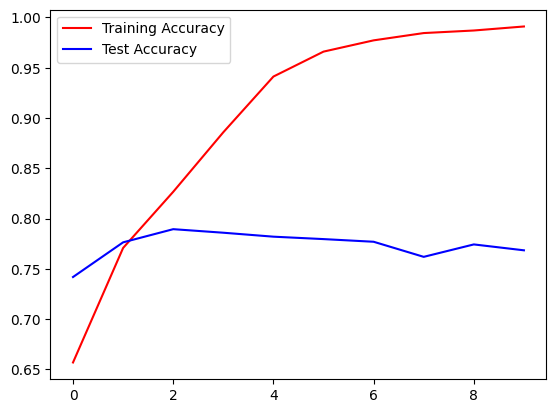

In [17]:
import matplotlib.pyplot as plt

plt.plot(model_history.history["accuracy"],color="red",label="Training Accuracy")
plt.plot(model_history.history["val_accuracy"],color="blue",label="Test Accuracy")
plt.legend()
plt.show()

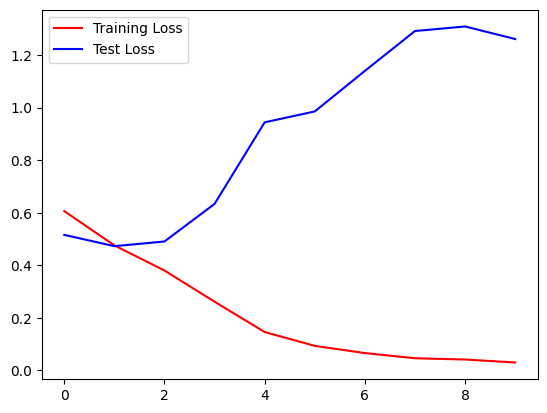

In [18]:
plt.plot(model_history.history["loss"],color="red",label="Training Loss")
plt.plot(model_history.history["val_loss"],color="blue",label="Test Loss")
plt.legend()
plt.show()

In [ ]:
# the plots indicates the model is not generalising well to new data
# to reduce overfitting, we will apply dropout and batch normalization techniques

## Ater Normalization

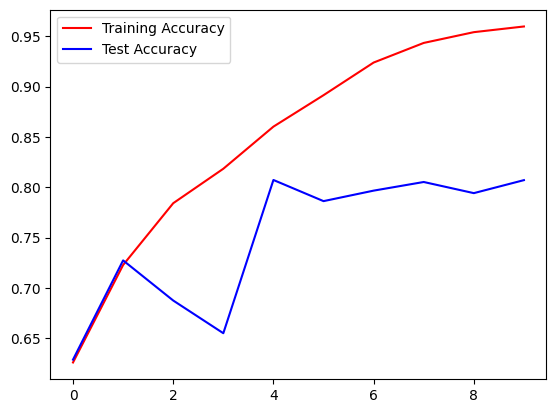

In [32]:
plt.plot(model_history.history["accuracy"],color="red",label="Training Accuracy")
plt.plot(model_history.history["val_accuracy"],color="blue",label="Test Accuracy")
plt.legend()
plt.show()

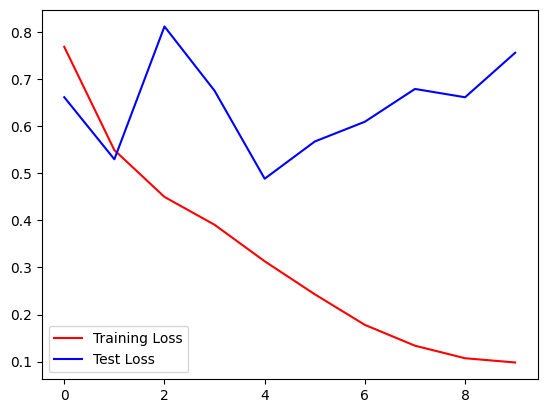

In [33]:
plt.plot(model_history.history["loss"],color="red",label="Training Loss")
plt.plot(model_history.history["val_loss"],color="blue",label="Test Loss")
plt.legend()
plt.show()

In [34]:
import cv2

In [35]:
cat=cv2.imread("/content/cat.jpg")
cat=cv2.cvtColor(cat,cv2.COLOR_BGR2RGB)

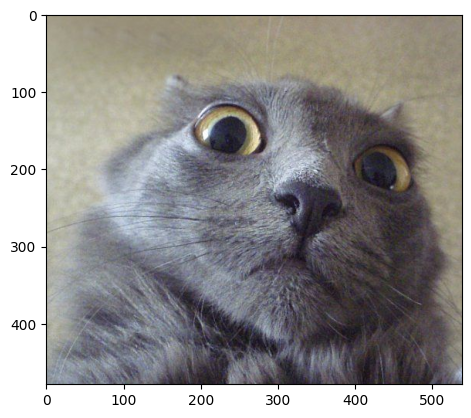

In [36]:
plt.imshow(cat)

In [37]:
cat.shape

(479, 539, 3)

In [38]:
cat=cv2.resize(cat,(256,256))

In [40]:
input_image=cat.reshape((1,256,256,3)) #converting the cat image into a 4d tensor

In [41]:
model.predict(input_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[1.2393669e-28]], dtype=float32)

In [ ]:
# since the predicted val is close to zero, the image belongs to clas 0. meow